In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

In [9]:
trades = pd.read_csv("historical_data.csv")
sentiment = pd.read_csv("fear_greed_index.csv")

print("Trades shape:", trades.shape)
print("Sentiment shape:", sentiment.shape)

Trades shape: (211224, 16)
Sentiment shape: (2644, 4)


In [13]:
trades.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


In [11]:
sentiment.head()

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [25]:
print(sentiment["classification"].value_counts())
print(sentiment["classification"].isnull().sum())

classification
Fear             781
Greed            633
Extreme Fear     508
Neutral          396
Extreme Greed    326
Name: count, dtype: int64
0


In [18]:
trades["datetime"] = pd.to_datetime(trades["Timestamp IST"], format="%d-%m-%Y %H:%M")
trades["date"] = trades["datetime"].dt.date

sentiment["date"] = pd.to_datetime(sentiment["date"]).dt.date

trades[["Timestamp IST","datetime","date"]].head()

,Timestamp IST,datetime,date
0,02-12-2024 22:50,2024-12-02 22:50:00,2024-12-02
1,02-12-2024 22:50,2024-12-02 22:50:00,2024-12-02
2,02-12-2024 22:50,2024-12-02 22:50:00,2024-12-02
3,02-12-2024 22:50,2024-12-02 22:50:00,2024-12-02
4,02-12-2024 22:50,2024-12-02 22:50:00,2024-12-02


In [33]:
df = trades.merge(sentiment[["date","classification"]],on = "date" , how = "left")
df = df.dropna(subset = ["classification"])

print(f"Merged Df shape: {df.shape}")
print(df["classification"].value_counts())

Merged Df shape: (211218, 20)
classification
Fear             61837
Greed            50303
Extreme Greed    39992
Neutral          37686
Extreme Fear     21400
Name: count, dtype: int64


In [42]:
df["Closed PnL"] = pd.to_numeric(df["Closed PnL"], errors = "coerce")
df["Is_win"] = df["Closed PnL"]>0

closes = df[df["Closed PnL"] != 0].copy()
print(f"Closed Trades : {closes.shape[0]}")

Closed Trades : 104402


In [44]:
summary = closes.groupby('classification').agg(
    avg_pnl=('Closed PnL', 'mean'),
    median_pnl=('Closed PnL', 'median'),
    total_pnl=('Closed PnL', 'sum'),
    win_rate=('Is_win', 'mean'),
    avg_size_usd=('Size USD', 'mean'),
    trade_count=('Closed PnL', 'count')
).round(3)

summary

,avg_pnl,median_pnl,total_pnl,win_rate,avg_size_usd,trade_count
classification,,,,,,
Extreme Fear,71.027,6.388,739110.248,0.762,5467.570,10406
Extreme Greed,130.205,8.531,2715171.311,0.892,2779.564,20853
Fear,112.626,6.350,3357155.442,0.873,8041.140,29808
Greed,85.404,4.928,2150129.273,0.769,5438.672,25176
Neutral,71.200,4.583,1292920.676,0.824,5556.445,18159


In [46]:
def simplify(c):
    if 'Fear' in c:
        return 'Fear'
    elif 'Greed' in c:
        return 'Greed'
    return 'Neutral'

closes['sentiment_simple'] = closes['classification'].apply(simplify)

summary_simple = closes.groupby('sentiment_simple').agg(
    avg_pnl=('Closed PnL', 'mean'),
    win_rate=('Is_win', 'mean'),
    avg_size_usd=('Size USD', 'mean'),
    trade_count=('Closed PnL', 'count')
).round(3)

summary_simple

,avg_pnl,win_rate,avg_size_usd,trade_count
sentiment_simple,,,,
Fear,101.862,0.844,7375.189,40214
Greed,105.701,0.825,4233.988,46029
Neutral,71.200,0.824,5556.445,18159


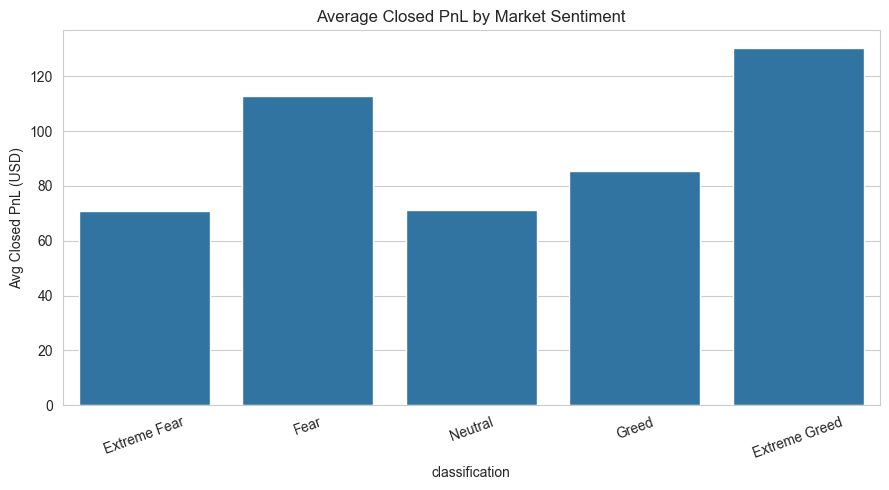

In [47]:
order = ['Extreme Fear', 'Fear', 'Neutral', 'Greed', 'Extreme Greed']
order = [o for o in order if o in summary.index]

plt.figure(figsize=(9, 5))
sns.barplot(x=summary.index, y=summary['avg_pnl'], order=order)
plt.title("Average Closed PnL by Market Sentiment")
plt.ylabel("Avg Closed PnL (USD)")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

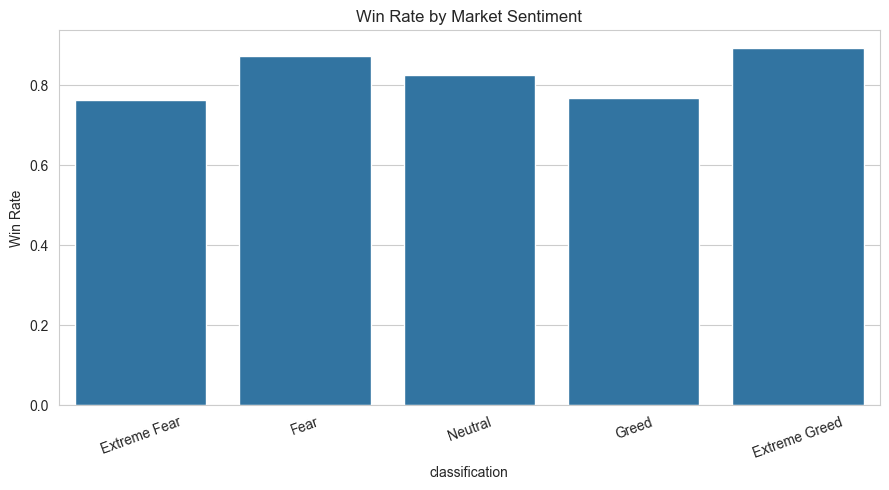

In [48]:
plt.figure(figsize=(9, 5))
sns.barplot(x=summary.index, y=summary['win_rate'], order=order)
plt.title("Win Rate by Market Sentiment")
plt.ylabel("Win Rate")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

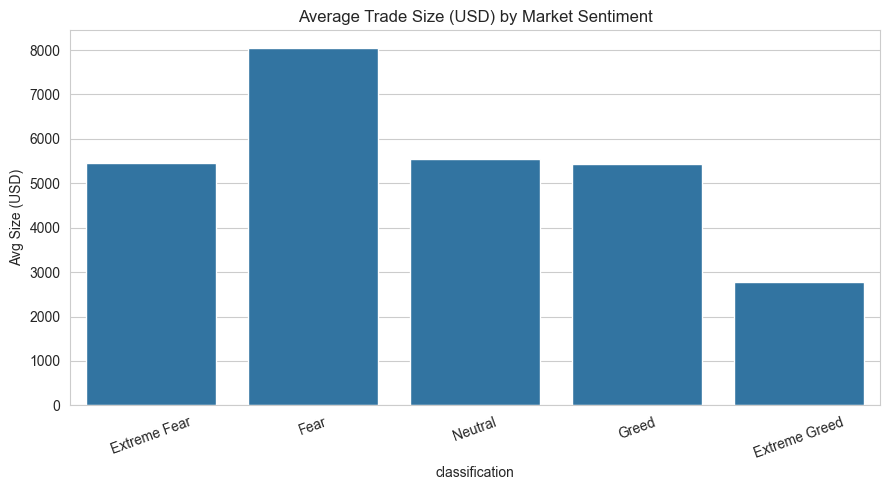

In [49]:
plt.figure(figsize=(9, 5))
sns.barplot(x=summary.index, y=summary['avg_size_usd'], order=order)
plt.title("Average Trade Size (USD) by Market Sentiment")
plt.ylabel("Avg Size (USD)")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

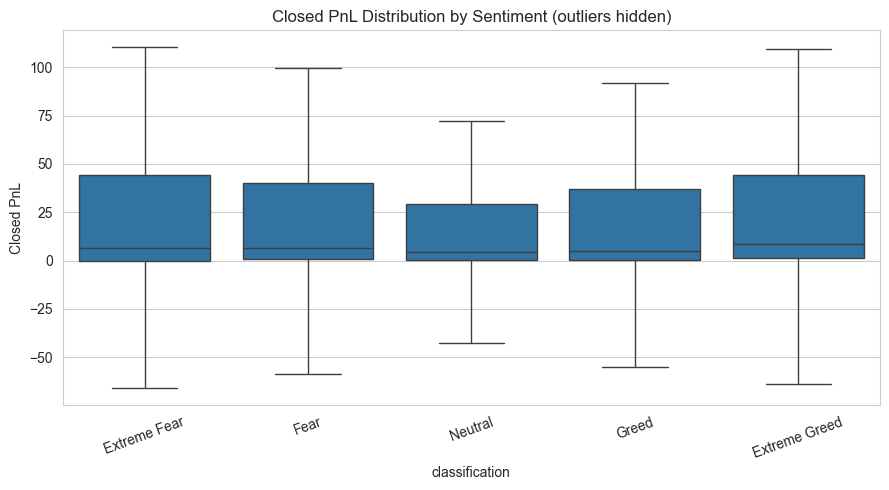

In [50]:
plt.figure(figsize=(9, 5))
sns.boxplot(x='classification', y='Closed PnL', data=closes, order=order, showfliers=False)
plt.title("Closed PnL Distribution by Sentiment (outliers hidden)")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()